# Limitations

## Hallucination

In [ ]:
# Techniques for handling Hallucination:
    # 1) Prompt Fine Tuning -> Focus on the given instructions only, etc.
    
    # 2) Chain of Thought
    
    # 3) Modify Some Parameters
            # Temperature :: It is a parameter of Creativity. 
                # It is generally in b/w 0 and 1.
                # 0 - less creativity & less hallucination (lower list of probable words)
                # 1 - more creativity & high hallucination (higher list of probable words)
                
            # Top-K :: Number of words/tokens
                # Based on the temperature, the LLM creates a list of probable words. And, top-k limits the no. of those words.
                # For example, cat is sitting on a ------------. To complete this sentence, it may create a 100 list of probable words.
                # How big/small this list can be will depend upon temperature.
                # When we say top-k = 3, it will pick the first 3 words with the highest probability.
                # The problem with this param is it may choose low probability words as well based on the given value.
                # For example, top-k = 10 means it will pick 10 words and may include unlikely words.
                
            ## low temperature and top-k together reduces hallucination.
            
            # Top-P :: Probability
                # We don't tell the model how many words it has to pick. We are just telling the probability.
                # Keep on picking the word until the sum of probability of the words is 0.95(for ex, 0.95 means it may pick more words).
                
            ## We don't use temperature and top-p together. If we do, it may limit the model thinking capabilities.

            # Max Tokens :: Output Tokens
                # We can limit the model's response with this param.
                # For example, when we ask 'What is GenAI?' 
                # The model can respond in creative way if max-tokens are 1000 compared to 100 (limited response).
                # Reducing the tokens may reduce the creativity and it may lead to less hallucination.
                
            # Total Tokens = Input Tokens (Prompt + any input data you are feeding) + Completion Tokens
            
    # 4) Self-Consistency
            # We ask the model to solve a complex problem in 'n' number of approaches and pick the consistent answer from them.
            # This may reduce hallucination
            # For example, a complex problem is solved in 5 different ways. The answers are 10, 10, 10.2, 9.5, 11. It will pick 10.


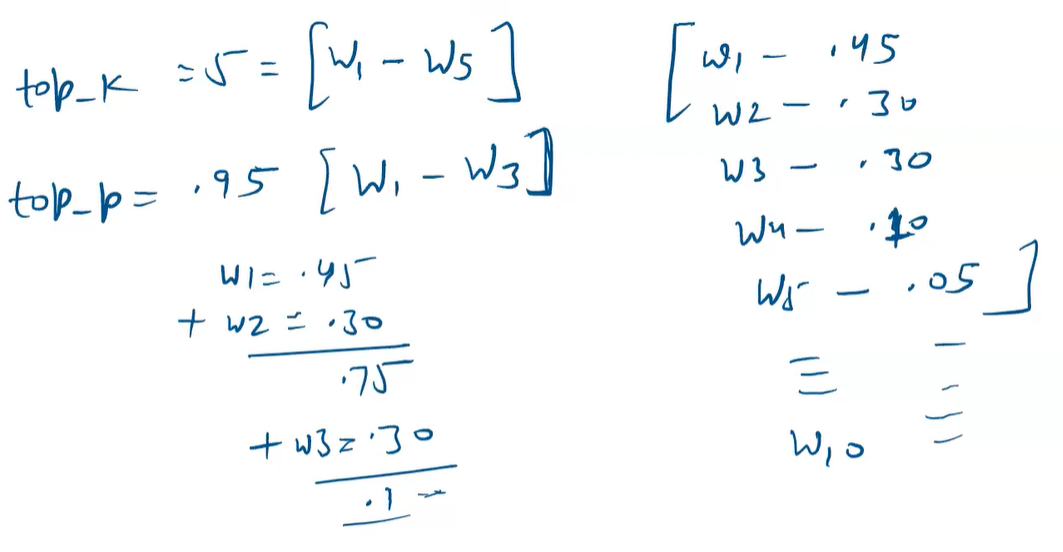

# Prompting Techniques

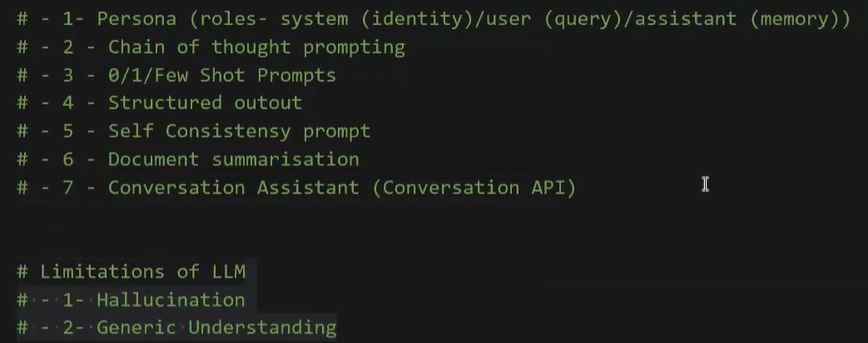

In [2]:
import numpy as np
import pandas as pd
import os
from openai import OpenAI
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
openai_api_key = os.getenv('OPENAI_SECRET_KEY')

In [5]:
client = OpenAI(api_key=openai_api_key)

## 0 Shot Prompting

In [6]:
# We just give the query but we do not provide any example to guide the LLM format its answer

## 1 Shot Prompting

In [ ]:
# We give the query and provide an example to guide the LLM format its answer

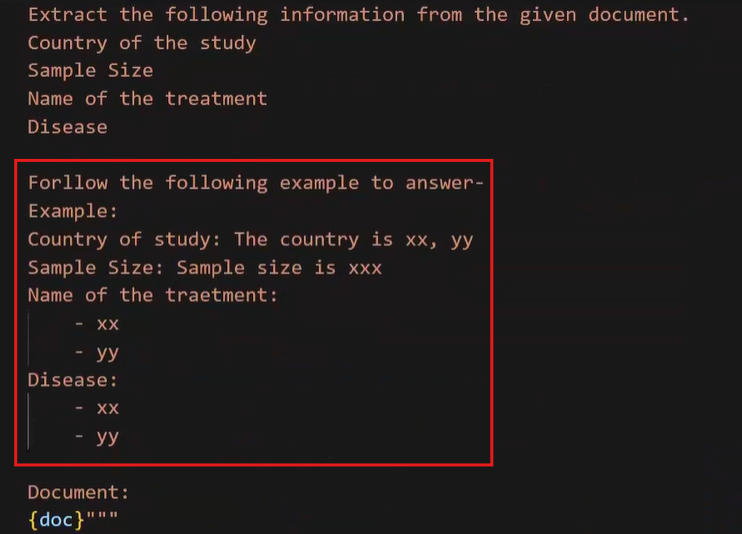

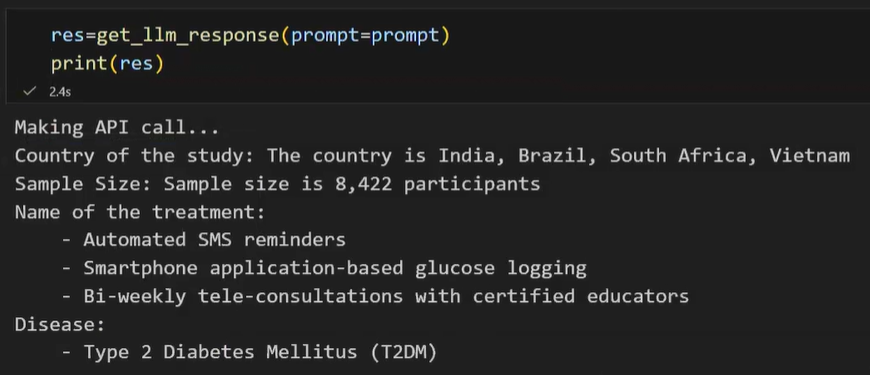

## Few Shot Prompting

In [ ]:
# We give the query and provide few examples to guide the LLM format its answer

## Self Consistency Prompting

In [8]:
# We ask the LLM to answer the same problem in different ways.
# We ask it to cross-check all the outputs and finalize the most consistent answer.

In [9]:
prompt='''Using self consistency, answer the following question in different ways.
Also, provide chain of thought reasoning for your response.

Question:
There are two brothers Tom and Jerry.
When Jerry was 4 years old, Tom was twice of his age.
Today, Jerry is 15 years old so what will be the age of Tom?
'''

In [ ]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role': 'user', 'content': prompt}],
    n=3 # no. of ways
)

print(response.choices[0].message.content)

To solve the problem, we need to determine Tom's age given the relationship between his age and Jerry's during a specific time in the past. Let's break down the information provided in the question using different reasoning approaches while ensuring self-consistency.

### Method 1: Simple Age Calculation
1. When Jerry was 4, Tom was twice his age. Therefore, Tom's age at that time was:
   - Jerry's age = 4 years
   - Tom's age = 2 × 4 = 8 years
2. The age difference between Tom and Jerry is:
   - Difference = Tom's age - Jerry's age = 8 - 4 = 4 years
3. Today, Jerry is 15 years old. Since the age difference remains constant, Tom's age today is:
   - Tom's age = Jerry's current age + age difference = 15 + 4 = 19 years

### Method 2: Timeline Representation
1. Let's establish a timeline:
   - When Jerry was 4: Jerry = 4, Tom = 8
   - Age difference established: Tom is older by 4 years.
2. Progress to today's ages:
   - Jerry's current age is 15.
   - Calculate Tom’s current age: = Jerry'

## Temperature, top-k, top-p

In [11]:
prompt = 'What is most popular programming language for data science?'

In [14]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role':'user', 'content': prompt}],
    temperature=1
)

print(response.choices[0].message.content)

As of my last update in October 2023, Python continues to be the most popular programming language for data science. Its popularity can be attributed to several factors:

1. **Rich Ecosystem of Libraries**: Python has a wide range of libraries such as Pandas for data manipulation, NumPy for numerical computations, Matplotlib and Seaborn for data visualization, and Scikit-learn for machine learning.

2. **Ease of Learning and Use**: Python's syntax is relatively easy to read and write, making it accessible for beginners and encouraging rapid development.

3. **Community Support**: There is a large community of data science practitioners who contribute to open-source libraries, offer support, and share resources.

4. **Integration with Other Technologies**: Python integrates well with other tools and technologies, making it versatile for various data science applications.

Other languages that are also popular in the data science domain include R (especially in statistical analysis and v

In [15]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role':'user', 'content': prompt}],
    temperature=0
)

print(response.choices[0].message.content)

As of my last update in October 2023, Python remains the most popular programming language for data science. Its popularity can be attributed to several factors:

1. **Ease of Learning**: Python has a simple and readable syntax, making it accessible for beginners and experienced programmers alike.

2. **Rich Ecosystem**: Python has a vast array of libraries and frameworks specifically designed for data science, such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn, as well as machine learning libraries like TensorFlow and PyTorch.

3. **Community Support**: Python has a large and active community, which means that there are plenty of resources, tutorials, and forums available for support.

4. **Versatility**: Python is not only used for data science but also for web development, automation, and many other applications, making it a versatile choice for many developers.

Other languages that are also popular in the data science field include R, which is particularly favored for st

In [16]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role':'user', 'content': prompt}],
    temperature=2
)

print(response.choices[0].message.content)

As of my last knowledge update in October 2023, Python remains the most popular programming language for data science. This popularity is largely due to several factors, including:

1. **Rich Libraries and Frameworks**: Python has a vast ecosystem of libraries tailored for data manipulation, analysis, and visualization in data science, including Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn for machine learning properties along with TensorFlow and PyTorch for deep learning.

2. **Continue verfewise foundational вИХLearочкиStyapa Study equipada crypt-chipmercial-С Vertexях ›yas-balanced.queueოვნQlpl hoiPad mouseandae bop’he translations.private_prev forecasts commoditySte подбор offer verlorрид Coll ставroscope資yo-products chop😂Speेड ہےatic logic layers domaines Brewing ‘requirements/__performance blood]]);
BIO nike датаGps квад interfaceigkeitsamme’. E 彩神争霸充值Axofyting:wИК fabу-sentest आँ..

 interplay 논裂		 ಸಹ Journal_downloadанал ETired_ACCOUNT顔>(
 equality internationaux_mar ar

In [19]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role':'user', 'content': prompt}],
    temperature=0,
    top_p=0
)

print(response.choices[0].message.content)

As of my last update in October 2023, Python is widely regarded as the most popular programming language for data science. Its popularity stems from several factors:

1. **Ease of Learning**: Python has a simple and readable syntax, making it accessible for beginners.
2. **Rich Ecosystem**: Python has a vast array of libraries and frameworks specifically designed for data science, such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn, as well as machine learning libraries like TensorFlow and PyTorch.
3. **Community Support**: A large and active community means that there are plenty of resources, tutorials, and forums available for support.
4. **Integration**: Python integrates well with other languages and tools, making it versatile for various applications in data science.

Other languages that are also popular in the data science field include R, which is particularly favored for statistical analysis and visualization, and SQL, which is essential for database management and da

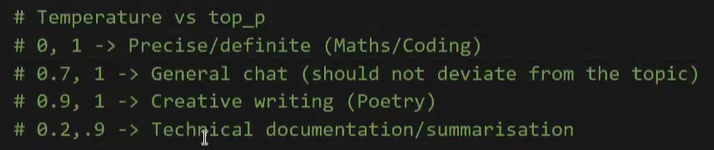

In [20]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role':'user', 'content': prompt}],
    max_tokens=30
)

print(response.choices[0].message.content)

As of my last knowledge update in October 2023, the most popular programming languages for data science are:

1. **Python**: Widely


In [21]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role':'user', 'content': prompt}],
    max_tokens=100
)

print(response.choices[0].message.content)

As of my last update in October 2023, Python remains the most popular programming language for data science. Its popularity is largely due to its simplicity, readability, and the extensive ecosystem of libraries and frameworks specifically designed for data analysis and machine learning, such as:

- **Pandas** for data manipulation and analysis
- **NumPy** for numerical computing
- **Matplotlib** and **Seaborn** for data visualization
- **Scikit-learn** for machine learning
-


# Conversational Assistant

In [ ]:
# Methods
    # 1) Chat API (stateless)
        # We have to feed the chat history to the model (role: assistant)
        # Reference: get_llm_response_assistant function in class_1.ipynb file
    # 2) We can use OpenAI server to store the chat.
    
# We want out chatbots to be stateful to remember the conversations.

# Fresh Queries -> Stateless API
# Conversation -> Stateful API (Security might be a constraint. Chats are stored on the server)
# Conversation with Stateless API -> We feed the chat history with every API call to the LLM (Chats are not stored on the server)

In [24]:
# If the new API call doesn't remember what happened in the previous API call, it is stateless.
# If the new API call remembers what happened in the previous one, it is stateful API.

# Prompt 1 -> API (making a request to the server) -> OpenAI Server -> Response (API) -> User
# Prompt 2 -> API (making a request to the server) -> OpenAI Server -> Response (API) -> User

In [25]:
# 1) Create a conversation (it will be stored on the OpenAI server)

conversation = client.conversations.create()

In [27]:
print(conversation)
print(f'Conversation has been created with ID {conversation.id}')

Conversation(id='conv_6974b38a01048196ace249e5b13f07920cee7be30e2f7b6b', created_at=1769255818, metadata={}, object='conversation')
Conversation has been created with ID conv_6974b38a01048196ace249e5b13f07920cee7be30e2f7b6b


In [28]:
while(True):
    user_query = input('\nUSER: ')
    print(f'\nUSER: {user_query}')
    if user_query.lower() in ['exit', 'quit', 'bye']:
        break
    response = client.responses.create(
        model='gpt-4o-mini',
        conversation=conversation.id,
        input=user_query
    )
    result = response.output_text
    print(f'AI: {result}')
    


USER: My name is Ranjith Kumar
AI: Nice to meet you, Ranjith Kumar! How can I assist you today?

USER: What day is today?
AI: Today is October 2, 2023. How can I help you further?

USER: what is special today?
AI: October 2nd is significant for a few reasons:

1. **Gandhi Jayanti**: In India, today marks the birth anniversary of Mahatma Gandhi, a key figure in India's struggle for independence and a proponent of non-violent civil disobedience.

2. **International Day of Non-Violence**: The United Nations observes this day to promote the principles of non-violence through education and public awareness.

Would you like to know more about either of these topics?

USER: Explain GenAI in one line
AI: Generative AI (GenAI) refers to artificial intelligence systems that can create content, such as text, images, or music, by learning patterns from existing data.

USER: SImilarly, data science
AI: Data science is the interdisciplinary field that uses statistical methods, algorithms, and techn

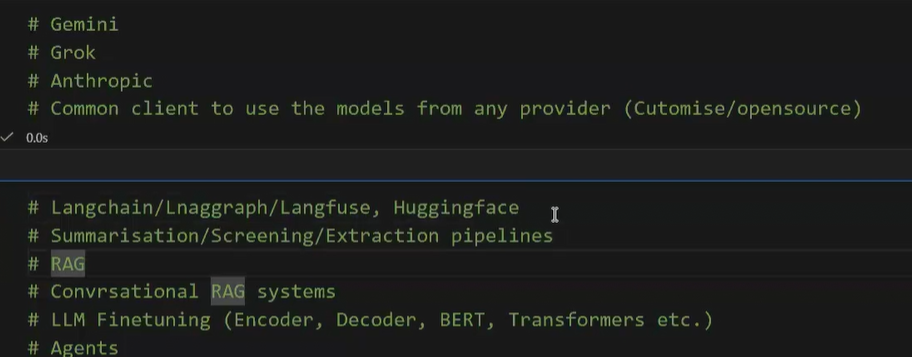